# U4A1 — Proyecto Integrador bajo la Metodología CRISP-DM
## Predicción del Rendimiento Académico en la Prueba Saber 11° (2020-2)

**Autor:** Luis Carlos Orozco Padilla  
**Curso:** Aprendizaje de Máquinas  
**Maestría en Ciencia de Datos**  


## 1. Entendimiento del Negocio

### Definición del Problema Predictivo
El objetivo central de esta investigación es construir un modelo predictivo capaz de estimar el rendimiento académico global de los estudiantes de educación media en Colombia, medido a través del atributo continuo `PUNT_GLOBAL` en las pruebas de Estado Saber 11°. Desde la perspectiva de las tareas del aprendizaje automático, este requerimiento se modela bajo un enfoque de **regresión supervisada** utilizando variables predictoras de carácter sociodemográfico, económico, familiar y del entorno del establecimiento educativo.

### Objetivos Técnicos
* Implementar, entrenar y contrastar cinco modelos clásicos de regresión.
* Implementar arquitecturas avanzadas de ensamble (Votación, Bagging y Boosting).
* Validar la generalización del modelo mediante validación cruzada de 5 particiones (5-Fold CV) sobre el conjunto de entrenamiento (70%).
* Seleccionar y serializar el estimador de mejor rendimiento relativo para su posterior integración en una aplicación web interactiva (Streamlit).

In [1]:
!pip -q install ydata-profiling

import json, time, joblib, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.8 MB/s eta 0:00:00


## 2. Carga y Entendimiento de los Datos

Con el objetivo de garantizar la eficiencia de cómputo y la viabilidad del proceso iterativo en un entorno de recursos limitados, se construye una muestra de **30.000 registros**, seleccionada aleatoriamente dentro de estratos definidos por cuantiles de `PUNT_GLOBAL`, con el fin de conservar la distribución del objetivo y reducir el costo computacional. Esta muestra se utiliza para el modelamiento experimental; no se afirma que sea una muestra probabilística representativa en sentido estadístico del universo.

En esta etapa se documenta:
* Las dimensiones de la matriz de entrada.
* La estructura general de las observaciones (inspección de las primeras filas).
* La prevalencia de valores faltantes (nulos) por columna, paso crítico previo al diseño del pipeline de preprocesamiento.

In [2]:
uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name, low_memory=False)
print(f"Archivo: {file_name}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
display(df.head())
print("\nPorcentaje de nulos por variable (top 10):")
display((df.isna().mean()*100).sort_values(ascending=False).head(10).round(2))

Saving Saber_11°_2020-2_20260916 (1).csv to Saber_11°_2020-2_20260916 (1).csv
Archivo: Saber_11°_2020-2_20260916 (1).csv
Dimensiones: 504,872 filas x 36 columnas


,ESTU_GENERO,ESTU_PAIS_RESIDE,ESTU_TIENEETNIA,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,ESTU_MCPIO_RESIDE,ESTU_COD_RESIDE_MCPIO,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_CUARTOSHOGAR,...,COLE_BILINGUE,COLE_CARACTER,COLE_AREA_UBICACION,COLE_JORNADA,COLE_MCPIO_UBICACION,COLE_DEPTO_UBICACION,PUNT_GLOBAL,ESTU_NACIONALIDAD,FAMI_TIENESERVICIOTV,COLE_GENERO
0,F,SUIZA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Estrato 2,5 a 6,Dos,...,N,ACADÉMICO,RURAL,UNICA,CAJICÁ,CUNDINAMARCA,244,SUIZA,Si,MIXTO
1,M,VENEZUELA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Estrato 3,3 a 4,Uno,...,N,ACADÉMICO,RURAL,NOCHE,CHÍA,CUNDINAMARCA,238,VENEZUELA,Si,MIXTO
2,F,VENEZUELA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Estrato 1,5 a 6,Uno,...,N,ACADÉMICO,RURAL,UNICA,CAJICÁ,CUNDINAMARCA,325,VENEZUELA,Si,MIXTO
3,M,VENEZUELA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Sin Estrato,5 a 6,Dos,...,N,ACADÉMICO,RURAL,UNICA,CAJICÁ,CUNDINAMARCA,238,VENEZUELA,Si,MIXTO
4,F,COLOMBIA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Estrato 5,5 a 6,Tres,...,N,TÉCNICO/ACADÉMICO,URBANO,UNICA,CAJICÁ,CUNDINAMARCA,202,COLOMBIA,Si,MIXTO



Porcentaje de nulos por variable (top 10):


,0
COLE_BILINGUE,16.44
FAMI_TIENECOMPUTADOR,4.00
FAMI_TRABAJOLABORPADRE,3.90
FAMI_TIENEAUTOMOVIL,3.53
FAMI_TRABAJOLABORMADRE,3.49
FAMI_TIENECONSOLAVIDEOJUEGOS,3.46
FAMI_TIENEMOTOCICLETA,3.38
ESTU_HORASSEMANATRABAJA,3.36
FAMI_ESTRATOVIVIENDA,3.36
FAMI_TIENELAVADORA,3.22


### Evaluación de Calidad de Datos
La inspección inicial revela la existencia de nulos en variables de contexto sociodemográfico relevantes. Metodológicamente, se determina que el tratamiento de estos valores ausentes se integrará directamente dentro de la arquitectura de la tubería de datos (*pipelines*) de Scikit-Learn. Esto asegura que los parámetros de imputación (en este proyecto, la categoría más frecuente para las variables categóricas) se calculen exclusivamente con los datos de entrenamiento de cada pliegue en la validación cruzada, evitando el sesgo de fuga de información de los datos de prueba.

## 3. Análisis de la Variable Objetivo: Distribución de `PUNT_GLOBAL`

Nulos en PUNT_GLOBAL: 0
Mínimo: 0 Máximo: 500
Media: 248.35 Mediana: 245.0
Q1: 211.0 Q3: 282.0
Registros con PUNT_GLOBAL=0: 80


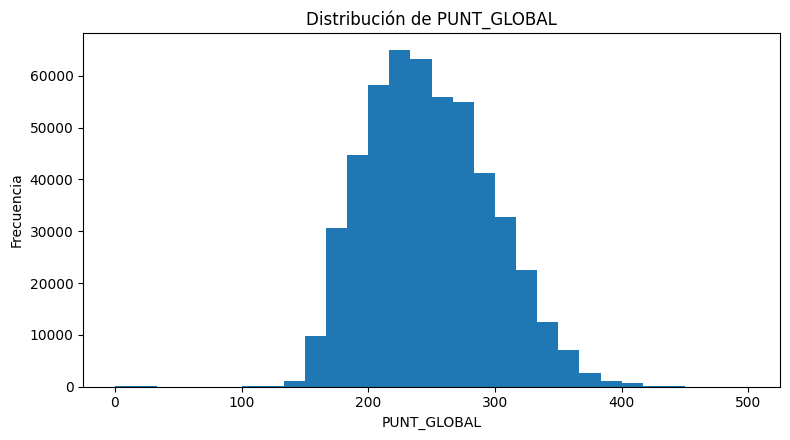

In [3]:
features = [
    'ESTU_GENERO','ESTU_TIENEETNIA','ESTU_DEPTO_RESIDE','FAMI_ESTRATOVIVIENDA',
    'FAMI_PERSONASHOGAR','FAMI_CUARTOSHOGAR','FAMI_EDUCACIONPADRE','FAMI_EDUCACIONMADRE',
    'FAMI_TRABAJOLABORPADRE','FAMI_TRABAJOLABORMADRE','FAMI_TIENEINTERNET','FAMI_TIENECOMPUTADOR',
    'FAMI_TIENELAVADORA','FAMI_TIENEAUTOMOVIL','FAMI_TIENEMOTOCICLETA','FAMI_TIENECONSOLAVIDEOJUEGOS',
    'FAMI_NUMLIBROS','ESTU_DEDICACIONLECTURADIARIA','ESTU_DEDICACIONINTERNET','ESTU_HORASSEMANATRABAJA',
    'COLE_NATURALEZA','COLE_CALENDARIO','COLE_BILINGUE','COLE_CARACTER','COLE_AREA_UBICACION',
    'COLE_JORNADA','COLE_GENERO'
]
y_all = pd.to_numeric(df['PUNT_GLOBAL'], errors='coerce')
print('Nulos en PUNT_GLOBAL:', int(y_all.isna().sum()))
print('Mínimo:', y_all.min(), 'Máximo:', y_all.max())
print('Media:', round(y_all.mean(),2), 'Mediana:', y_all.median())
print('Q1:', y_all.quantile(.25), 'Q3:', y_all.quantile(.75))
print('Registros con PUNT_GLOBAL=0:', int((y_all==0).sum()))

plt.figure(figsize=(8,4.5));
plt.hist(y_all.dropna(), bins=30);
plt.xlabel('PUNT_GLOBAL');
plt.ylabel('Frecuencia');
plt.title('Distribución de PUNT_GLOBAL');
plt.tight_layout();
plt.show()

### Caracterización de la Variable Objetivo
* **Rango Teórico y Empírico:** Se confirma que los datos observados se sitúan dentro de la escala oficial del examen (0 a 500 puntos).
* **Comportamiento en Cero:** Se detecta un subconjunto de 80 registros con puntuación igual a cero. Al no disponer de evidencia de fallo en el sistema de captura de datos o de fraude sistémico, se decide conservarlos en la muestra para evitar la exclusión sesgada de casos atípicos.
* **Distribución de Frecuencias:** La distribución de la variable objetivo es unimodal y se concentra alrededor de la zona central de la escala, con dispersión hacia valores altos y bajos. Para controlar el costo computacional, la selección de los 30.000 registros se hizo por cuantiles de `PUNT_GLOBAL`; esto ayuda a conservar la distribución del objetivo en la muestra de modelado. La partición 70/30 posterior es aleatoria y no utiliza `stratify` en `train_test_split`.

## 4. Partición del Conjunto de Datos y Control de Sesgo

Para evitar cualquier riesgo de *Data Leakage*, primero se construye la muestra de modelado mediante estratos por cuantiles de `PUNT_GLOBAL`; posteriormente, esta muestra se divide aleatoriamente en entrenamiento (70%) y prueba (30%) con `train_test_split`. La estratificación por cuantiles se aplica a la selección de la muestra de 30.000, no al `train_test_split` mostrado en el código.

In [4]:
y = y_all.copy()
mask = y.notna()
X = df.loc[mask, features].copy()
y = y.loc[mask].copy()

# Estratificación por intervalos del objetivo para conservar la distribución en la muestra de 30.000.
work = X.copy()
work['PUNT_GLOBAL'] = y.values
work['_bin'] = pd.qcut(work['PUNT_GLOBAL'], q=20, duplicates='drop')
parts=[]
for _, g in work.groupby('_bin', observed=True):
    n=max(1, round(30000*len(g)/len(work)))
    parts.append(g.sample(n=min(n,len(g)), random_state=RANDOM_STATE))
work=pd.concat(parts).sample(30000, random_state=RANDOM_STATE).drop(columns='_bin')
X=work[features].copy(); y=work['PUNT_GLOBAL'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=RANDOM_STATE)
print('Muestra de modelado:', X.shape)
print('Entrenamiento (70%):', X_train.shape)
print('Prueba (30%):', X_test.shape)

Muestra de modelado: (30000, 27)
Entrenamiento (70%): (21000, 27)
Prueba (30%): (9000, 27)


## 5. Diseño del Preprocesamiento

La formulación teórica de las familias de modelos de aprendizaje seleccionadas exige un procesamiento diferenciado de los datos:
* **Modelos Lineales (Regresión Lineal y Ridge):** Requieren la codificación numérica de variables categóricas. Se utiliza One-Hot Encoding con un umbral de frecuencia mínima para controlar la dimensionalidad.
* **Modelos Basados en Distancia (KNN):** Altamente sensibles a la escala de los datos y a la maldición de la dimensionalidad. Se diseña un pipeline específico para este algoritmo que integra la reducción de dimensionalidad mediante `TruncatedSVD` (30 componentes) seguida de un escalamiento estándar (`StandardScaler`).
* **Modelos Basados en Árboles (Árboles de Decisión y Random Forest):** No requieren estandarización de las variables y utilizan la reducción de error para seleccionar particiones; en estos modelos de regresión el criterio relevante es el error cuadrático (MSE / squared error), no Gini.

In [5]:
def make_preprocessor():
    return ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10))
        ]), features)
    ])

pre_check = make_preprocessor()
Xt_check = pre_check.fit_transform(X_train)
print('Dimensiones después de One-Hot:', Xt_check.shape)

cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'mae':'neg_mean_absolute_error','rmse':'neg_root_mean_squared_error','r2':'r2'}

Dimensiones después de One-Hot: (21000, 156)


## 6. Evaluación de la Línea Base

La evaluación de la línea base (*baseline*) tiene como finalidad cuantificar el desempeño de los modelos utilizando parametrizaciones de referencia fijadas antes del ajuste; no son necesariamente los valores por defecto de Scikit-Learn antes de iniciar cualquier proceso de optimización.

Este análisis responde a la necesidad de evaluar el beneficio marginal que aportará la sintonización fina de hiperparámetros. Las métricas calculadas incluyen el error absoluto medio (MAE) en validación cruzada (5-Fold CV) y sus correspondientes medidas de desempeño en el conjunto de prueba independiente para verificar la estabilidad de las estimaciones.

In [6]:
# CONFIGURACIÓN DE LÍNEA BASE
# Estas configuraciones son un punto de partida razonable, no son el resultado del tuning.
baseline_models = {
    'Regresión Lineal': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'KNN': KNeighborsRegressor(n_neighbors=15, weights='distance', n_jobs=2),
    'Árbol de Decisión': DecisionTreeRegressor(max_depth=18, min_samples_leaf=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=2)
}

base_rows=[]
for name, est in baseline_models.items():
    # El preprocesamiento está dentro del pipeline para que cada fold aprenda la imputación/One-Hot solo con sus datos.
    pipe = Pipeline([('pre', make_preprocessor()), ('model', est)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv5, scoring=scoring, n_jobs=1)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    base_rows.append([
        name,
        -cvres['test_mae'].mean(),
        cvres['test_mae'].std(),
        mean_absolute_error(y_test,pred),
        mean_squared_error(y_test,pred)**0.5,
        r2_score(y_test,pred)
    ])

base_df = pd.DataFrame(base_rows, columns=['Modelo','CV_MAE','CV_MAE_std','Test_MAE','Test_RMSE','Test_R2'])

# Menor MAE = mejor. Esta tabla es la referencia para el "antes".
display(base_df.sort_values('Test_MAE').round(3))
base_df.to_csv('baseline_resultados.csv', index=False)


,Modelo,CV_MAE,CV_MAE_std,Test_MAE,Test_RMSE,Test_R2
1,Ridge,31.431,0.127,31.214,39.230,0.351
0,Regresión Lineal,31.429,0.130,31.220,39.247,0.350
4,Random Forest,32.472,0.162,31.922,39.895,0.328
2,KNN,34.102,0.122,33.454,41.762,0.264
3,Árbol de Decisión,35.290,0.296,34.444,43.468,0.203


### Análisis de la Línea Base
Los resultados preliminares muestran que los modelos fundamentados en principios lineales de regularización obtienen un mejor desempeño inicial en términos de MAE. KNN, Árbol de Decisión y Random Forest parten de errores superiores a los modelos lineales. En particular, KNN es sensible a la representación y escala de las variables, mientras que el Árbol de Decisión muestra mayor variabilidad entre folds. Estos resultados motivan el ajuste posterior, pero por sí solos no permiten afirmar sobreajuste; para ello sería necesario contrastar también el error de entrenamiento.

## 7. Optimización de Hiperparámetros de los Modelos Clásicos

Con el fin de hacer viable el costo computacional de la búsqueda aleatoria e iterativa, el proceso de optimización mediante `RandomizedSearchCV` se ejecuta sobre una submuestra de 5.000 observaciones de entrenamiento, construida tomando 1.000 registros de cada uno de cinco estratos por cuantiles de `PUNT_GLOBAL`.

Una vez identificada la combinación óptima de hiperparámetros para cada algoritmo, el pipeline seleccionado se reentrena con los 21.000 registros de entrenamiento y se vuelve a evaluar mediante 5-Fold CV. Esta segunda evaluación permite verificar si la configuración encontrada en la submuestra de búsqueda mantiene un desempeño similar al utilizar todo el entrenamiento disponible.

### Espacios de Búsqueda:
* **Regresión Lineal (`fit_intercept`):** Explora la idoneidad matemática de forzar el paso por el origen de la recta de regresión.
* **Ridge (`alpha`):** Define el nivel de penalización L2 para controlar la multicolinealidad y reducir la varianza del estimador.
* **KNN (`n_neighbors`, `weights`, `p`):** Ajusta la densidad del vecindario de consulta, pondera la influencia relativa de la distancia y evalúa las métricas de distancia Manhattan ($p=1$) y Euclidiana ($p=2$).
* **Árbol de Decisión y Random Forest (`max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`):** Controlan el crecimiento y la complejidad estructural de los modelos basados en árboles para mitigar el sobreajuste, optimizando la capacidad de generalización.
### Rangos evaluados
Los rangos se definieron para cubrir desde configuraciones simples o con regularización baja hasta configuraciones más complejas, evitando espacios innecesariamente grandes. La búsqueda no es exhaustiva en todos los modelos: se evaluaron 2 configuraciones para Regresión Lineal, las 7 de Ridge, 6 de 24 posibles en KNN, 8 de 480 posibles en Árbol y 6 de 324 posibles en Random Forest. `random_state=42` permite reproducir la selección aleatoria.

- **Regresión Lineal — `fit_intercept` {True, False}:** permite comparar el modelo con y sin término independiente.
- **Ridge — `alpha` {0,01, 0,1, 1, 3, 10, 30, 100}:** escala logarítmicamente la intensidad de la regularización L2, cubriendo desde penalización casi nula hasta una regularización fuerte.
- **KNN — `n_neighbors` {5, 10, 15, 20, 30, 40}, `weights` {uniform, distance}, `p` {1,2}:** compara vecindarios pequeños y amplios, ponderación uniforme o por distancia, y distancias Manhattan o Euclidiana.
- **Árbol — `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`:** cubre árboles poco y muy profundos y distintos niveles mínimos de datos para dividir o formar hojas, además del número relativo de variables consideradas.
- **Random Forest — `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`:** explora número de árboles, profundidad y restricciones de tamaño para controlar complejidad y variabilidad.


In [7]:
# SUBMUESTRA PARA LA BÚSQUEDA INTENSIVA
# Se conserva la distribución de PUNT_GLOBAL usando 5 grupos por cuantiles; se toman 1.000 registros por estrato.
q = pd.qcut(y_train, q=5, duplicates='drop')
idx=[]
for _, g in y_train.groupby(q, observed=True):
    idx.extend(g.sample(n=min(1000, len(g)), random_state=RANDOM_STATE).index.tolist())
idx = idx[:5000]
X_dev = X_train.loc[idx].copy()
y_dev = y_train.loc[idx].copy()
print('Submuestra para RandomizedSearchCV:', X_dev.shape)

# ESPACIOS DE BÚSQUEDA
# Cada espacio de búsqueda cubre configuraciones con diferente complejidad, regularización o función de distancia. RandomizedSearchCV no recorre exhaustivamente todos los cruces en árboles y bosque.
spaces = {
    'Regresión Lineal': {'model__fit_intercept':[True,False]},
    'Ridge': {'model__alpha':[0.01,0.1,1,3,10,30,100]},
    'KNN': {'model__n_neighbors':[5,10,15,20,30,40], 'model__weights':['uniform','distance'], 'model__p':[1,2]},
    'Árbol de Decisión': {'model__max_depth':[5,8,12,16,20,None], 'model__min_samples_split':[2,5,10,20], 'model__min_samples_leaf':[1,2,5,10,20], 'model__max_features':[None,'sqrt','log2',0.5]},
    'Random Forest': {'model__n_estimators':[20,30,40], 'model__max_depth':[8,12,16,None], 'model__min_samples_split':[2,5,10], 'model__min_samples_leaf':[1,2,5], 'model__max_features':['sqrt',0.5,'log2']}
}

def knn_pipeline(est):
    # KNN necesita una representación compacta y escalada para que la distancia sea útil.
    return Pipeline([
        ('pre', make_preprocessor()),
        ('svd', TruncatedSVD(n_components=30, random_state=RANDOM_STATE)),
        ('scale', StandardScaler()),
        ('model', est)
    ])

estimators = {
    'Regresión Lineal': (Pipeline([('pre',make_preprocessor()),('model',LinearRegression())]), 2),
    'Ridge': (Pipeline([('pre',make_preprocessor()),('model',Ridge())]), 7),
    'KNN': (knn_pipeline(KNeighborsRegressor(algorithm='brute', n_jobs=2)), 6),
    'Árbol de Decisión': (Pipeline([('pre',make_preprocessor()),('model',DecisionTreeRegressor(random_state=RANDOM_STATE))]), 8),
    'Random Forest': (Pipeline([('pre',make_preprocessor()),('model',RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=2))]), 6)
}

searches={}
tuned={}
for name,(pipe,n_iter) in estimators.items():
    print(f'\nAjustando {name} ...')
    rs=RandomizedSearchCV(
        pipe,
        spaces[name],
        n_iter=n_iter,
        scoring=scoring,
        refit='mae',
        cv=cv5,
        random_state=RANDOM_STATE,
        n_jobs=1,
        return_train_score=False
    )
    rs.fit(X_dev,y_dev)
    searches[name]=rs

    # La mejor configuración encontrada se vuelve a entrenar con TODO el 70% de entrenamiento.
    best=rs.best_estimator_
    best.fit(X_train,y_train)
    tuned[name]=best
    print('Mejores parámetros:', rs.best_params_)

# Tabla resumen de los hiperparámetros ganadores.
best_params_df = pd.DataFrame([
    {'Modelo':name, 'Mejores parámetros': str(searches[name].best_params_), 'MAE búsqueda': -searches[name].best_score_}
    for name in searches
]).sort_values('MAE búsqueda')
display(best_params_df.round(4))
best_params_df.to_csv('mejores_parametros.csv', index=False)
print('Ajuste terminado.')


Submuestra para RandomizedSearchCV: (5000, 27)

Ajustando Regresión Lineal ...
Mejores parámetros: {'model__fit_intercept': False}

Ajustando Ridge ...
Mejores parámetros: {'model__alpha': 30}

Ajustando KNN ...
Mejores parámetros: {'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 30}

Ajustando Árbol de Decisión ...
Mejores parámetros: {'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': 5}

Ajustando Random Forest ...
Mejores parámetros: {'model__n_estimators': 20, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 12}


,Modelo,Mejores parámetros,MAE búsqueda
1,Ridge,{'model__alpha': 30},31.8326
0,Regresión Lineal,{'model__fit_intercept': False},31.9018
4,Random Forest,"{'model__n_estimators': 20, 'model__min_sample...",33.0815
2,KNN,"{'model__weights': 'uniform', 'model__p': 2, '...",34.0610
3,Árbol de Decisión,"{'model__min_samples_split': 5, 'model__min_sa...",34.9189


Ajuste terminado.


### Discusión sobre el Protocolo de Optimización
El uso combinado de `RandomizedSearchCV` y una submuestra de desarrollo permite explorar eficazmente espacios paramétricos de alta dimensionalidad. El posterior reentrenamiento sobre el conjunto total del 70% asegura que los parámetros seleccionados se beneficien del volumen completo de observaciones disponibles para el entrenamiento.
**Cómo leer esta etapa:** `best_params_` identifica la configuración con menor MAE promedio en los 5 folds de la submuestra de desarrollo. Después, esa configuración se ajusta con los 21.000 registros para que la comparación posterior use todo el entrenamiento disponible. Esto no garantiza que el MAE mejore frente a la línea base al cambiar de muestra; justamente por eso se realiza la reevaluación completa en la siguiente sección.


## 8. Evaluación Post-Optimización de Modelos Clásicos

A continuación, se consolida la estimación del desempeño final de las configuraciones optimizadas utilizando una validación cruzada completa de 5 particiones sobre la totalidad del conjunto de entrenamiento de 21.000 registros.

In [8]:
tuned_full70_rows=[]
for name, model in tuned.items():
    r=cross_validate(model,X_train,y_train,cv=cv5,scoring=scoring,n_jobs=1)
    tuned_full70_rows.append([
        name,-r['test_mae'].mean(),r['test_mae'].std(),-r['test_rmse'].mean(),r['test_r2'].mean()
    ])
tuned_full70_df=pd.DataFrame(tuned_full70_rows,columns=['Modelo','CV_MAE_full70','CV_MAE_std_full70','CV_RMSE_full70','CV_R2_full70'])
display(tuned_full70_df.sort_values('CV_MAE_full70'))

,Modelo,CV_MAE_full70,CV_MAE_std_full70,CV_RMSE_full70,CV_R2_full70
0,Regresión Lineal,31.428677,0.130241,39.347310,0.346220
1,Ridge,31.441759,0.122496,39.337094,0.346563
4,Random Forest,32.580557,0.129918,40.565103,0.305161
2,KNN,33.990849,0.201684,42.364822,0.242128
3,Árbol de Decisión,34.754254,0.177333,43.174623,0.212892


## 9. Análisis del Impacto de la Optimización de Hiperparámetros

En esta sección se evalúa cuantitativamente la diferencia en el desempeño de los modelos antes y después del proceso de sintonización fina de hiperparámetros.

El cambio se denota como:
$$\Delta \text{ Métrica} = \text{Métrica}_{\text{Optimizado}} - \text{Métrica}_{\text{Base}}$$

Donde una variación negativa en las métricas de error (MAE) representa una ganancia efectiva en la capacidad predictiva del modelo.

In [9]:
# Métricas de test de los modelos ajustados.
tuned_test_rows=[]
for name, model in tuned.items():
    pred=model.predict(X_test)
    tuned_test_rows.append([name,mean_absolute_error(y_test,pred),mean_squared_error(y_test,pred)**0.5,r2_score(y_test,pred)])
tuned_test_df=pd.DataFrame(tuned_test_rows,columns=['Modelo','Test_MAE_ajustado','Test_RMSE_ajustado','Test_R2_ajustado'])

compare = base_df.merge(tuned_full70_df[['Modelo','CV_MAE_full70']],on='Modelo')
compare = compare.merge(tuned_test_df,on='Modelo')
compare['Delta_CV_MAE']=compare['CV_MAE_full70']-compare['CV_MAE']
compare['Delta_Test_MAE']=compare['Test_MAE_ajustado']-compare['Test_MAE']
display(compare[['Modelo','CV_MAE','CV_MAE_std','CV_MAE_full70','Delta_CV_MAE','Test_MAE','Test_MAE_ajustado','Delta_Test_MAE']].round(4))

,Modelo,CV_MAE,CV_MAE_std,CV_MAE_full70,Delta_CV_MAE,Test_MAE,Test_MAE_ajustado,Delta_Test_MAE
0,Regresión Lineal,31.4287,0.1302,31.4287,-0.0000,31.2205,31.2205,0.0000
1,Ridge,31.4307,0.1274,31.4418,0.0111,31.2142,31.2131,-0.0010
2,KNN,34.1016,0.1224,33.9908,-0.1108,33.4541,33.6691,0.2150
3,Árbol de Decisión,35.2898,0.2964,34.7543,-0.5355,34.4440,34.1744,-0.2696
4,Random Forest,32.4723,0.1617,32.5806,0.1083,31.9215,32.0825,0.1610


### Evaluación Crítica del Proceso de Optimización
* **Modelos Lineales:** Muestran una ganancia marginal casi nula, lo que sugiere que la estructura lineal óptima se encontraba cercana a los valores predeterminados.
* **Modelos de Vecindad (KNN):** La configuración ajustada mejora el MAE de CV en 0,111 puntos, pero empeora el MAE de test en 0,215 puntos. Por tanto, la mejora observada en validación no se generalizó al conjunto de prueba; además, la comparación incluye el cambio de representación mediante SVD y escalamiento.
* **Modelos Basados en Árboles:** El Árbol de Decisión presenta la mayor mejora consistente entre CV y test (−0,536 y −0,270 puntos de MAE, respectivamente). Esto es compatible con que limitar profundidad, tamaño mínimo de hojas y divisiones ayude a controlar la complejidad; no se afirma causalidad más allá de esta comparación experimental.

## 10. Análisis de Sensibilidad: Efecto del Parámetro de Regularización `alpha` en Ridge

El hiperparámetro `alpha` determina la penalización sobre la magnitud de los coeficientes de regresión. Se evalúa un rango de variación logarítmica para trazar la curva de comportamiento del MAE frente al nivel de regularización aplicado.

,alpha,CV_MAE,CV_MAE_std,CV_RMSE,CV_R2
0,0.01,31.902005,0.600944,39.875142,0.328880
1,0.10,31.901078,0.600219,39.874188,0.328911
2,1.00,31.893416,0.595764,39.864669,0.329226
3,3.00,31.880935,0.588522,39.847128,0.329804
4,10.00,31.850635,0.563658,39.804053,0.331218
5,30.00,31.832573,0.521479,39.760596,0.332614
6,100.00,31.942144,0.484924,39.857599,0.329274


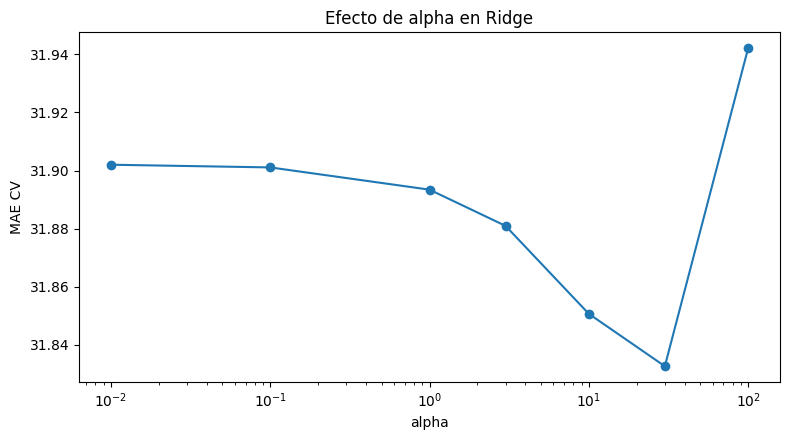

In [10]:
alpha_values=[0.01,0.1,1,3,10,30,100]
ridge_effect=[]
for a in alpha_values:
    pipe=Pipeline([('pre',make_preprocessor()),('model',Ridge(alpha=a))])
    r=cross_validate(pipe,X_dev,y_dev,cv=cv5,scoring=scoring,n_jobs=1)
    ridge_effect.append([a,-r['test_mae'].mean(),r['test_mae'].std(),-r['test_rmse'].mean(),r['test_r2'].mean()])
ridge_effect_df=pd.DataFrame(ridge_effect,columns=['alpha','CV_MAE','CV_MAE_std','CV_RMSE','CV_R2'])
display(ridge_effect_df)
plt.figure(figsize=(8,4.5)); plt.plot(ridge_effect_df.alpha,ridge_effect_df.CV_MAE,marker='o'); plt.xscale('log'); plt.xlabel('alpha'); plt.ylabel('MAE CV'); plt.title('Efecto de alpha en Ridge'); plt.tight_layout(); plt.show()

### Discusión del Análisis de Regularización
En la submuestra utilizada para explorar `alpha`, el menor MAE de CV se obtiene con `alpha=30` (31,833), seguido por `alpha=10` (31,851). Valores bajos presentan errores ligeramente mayores, mientras que `alpha=100` vuelve a aumentar el MAE (31,942). El comportamiento es consistente con una penalización demasiado fuerte cuando `alpha` aumenta, aunque el notebook no calcula error de entrenamiento y por tanto no prueba de forma directa el subajuste. En la reevaluación con los 21.000 registros, Ridge con `alpha=30` no mejora de forma material la línea base; esto se reporta explícitamente para evitar sobreinterpretar el ajuste de la submuestra.

## 11. Implementación de Modelos de Ensamble

Con el objetivo de maximizar la robustez del marco predictivo, se implementan tres metodologías avanzadas de ensamble:
* **Ensamble por Votación (Voting Regressor):** Promedia las estimaciones de tres modelos seleccionados por su buen comportamiento individual en la comparación experimental (Regresión Lineal, Ridge y Random Forest).
* **Ensamble por Agregación (Bagging Regressor):** Construye múltiples estimadores sobre submuestras con reemplazo con el objetivo de disminuir la sensibilidad del estimador base a una sola muestra de entrenamiento.
* **Ensamble por Impulso (Boosting Regressor):** Entrena estimadores secuenciales para que cada etapa reduzca parte del error residual de las anteriores.

In [11]:
# Voting con los tres modelos ajustados que mostraron mejor comportamiento individual.
voting = VotingRegressor([
    ('lr', tuned['Regresión Lineal']),
    ('ridge', tuned['Ridge']),
    ('rf', tuned['Random Forest'])
])

v_cv=cross_validate(voting,X_train,y_train,cv=cv5,scoring=scoring,n_jobs=1)
voting.fit(X_train,y_train)
pv=voting.predict(X_test)
voting_metrics={
    'CV_MAE':-v_cv['test_mae'].mean(), 'CV_MAE_std':v_cv['test_mae'].std(),
    'CV_RMSE':-v_cv['test_rmse'].mean(), 'CV_R2':v_cv['test_r2'].mean(),
    'Test_MAE':mean_absolute_error(y_test,pv), 'Test_RMSE':mean_squared_error(y_test,pv)**0.5, 'Test_R2':r2_score(y_test,pv)
}

# Bagging y Boosting en pipelines para mantener el preprocesamiento dentro de cada fold.
dt_base=DecisionTreeRegressor(max_depth=5,min_samples_split=5,min_samples_leaf=10,max_features=0.5,random_state=RANDOM_STATE)
bag_pipe=Pipeline([('pre',make_preprocessor()),('model',BaggingRegressor(estimator=dt_base,n_estimators=50,max_samples=0.8,random_state=RANDOM_STATE,n_jobs=2))])
gb_pipe=Pipeline([('pre',make_preprocessor()),('model',GradientBoostingRegressor(n_estimators=50,learning_rate=0.05,max_depth=3,min_samples_leaf=10,random_state=RANDOM_STATE))])

ensemble_rows=[]
for name,pipe in [('Voting',voting),('Bagging',bag_pipe),('Boosting',gb_pipe)]:
    if name=='Voting':
        m=voting_metrics
    else:
        cvres=cross_validate(pipe,X_train,y_train,cv=cv5,scoring=scoring,n_jobs=1)
        pipe.fit(X_train,y_train); pred=pipe.predict(X_test)
        m={
            'CV_MAE':-cvres['test_mae'].mean(),'CV_MAE_std':cvres['test_mae'].std(),
            'CV_RMSE':-cvres['test_rmse'].mean(),'CV_R2':cvres['test_r2'].mean(),
            'Test_MAE':mean_absolute_error(y_test,pred),'Test_RMSE':mean_squared_error(y_test,pred)**0.5,'Test_R2':r2_score(y_test,pred)
        }
    ensemble_rows.append([name,m['CV_MAE'],m['CV_MAE_std'],m['CV_RMSE'],m['CV_R2'],m['Test_MAE'],m['Test_RMSE'],m['Test_R2']])
ensemble_df=pd.DataFrame(ensemble_rows,columns=['Modelo','CV_MAE_full70','CV_MAE_std_full70','CV_RMSE_full70','CV_R2_full70','Test_MAE','Test_RMSE','Test_R2'])
display(ensemble_df.sort_values('Test_MAE'))

,Modelo,CV_MAE_full70,CV_MAE_std_full70,CV_RMSE_full70,CV_R2_full70,Test_MAE,Test_RMSE,Test_R2
0,Voting,31.428846,0.077892,39.236770,0.349902,31.110081,39.045161,0.356718
1,Bagging,33.939712,0.167542,42.089217,0.251971,33.583016,41.833195,0.261571
2,Boosting,33.887023,0.145570,41.844768,0.260634,33.587668,41.651922,0.267957


## 12. Comparación Consolidada de Candidatos y Selección del Modelo

Se presenta la matriz final de comparación que reúne las métricas de desempeño de las ocho configuraciones candidatas (cinco modelos clásicos optimizados y tres ensambles combinados).

La selección final del estimador se sustenta en tres criterios estadísticos:
1. Menor promedio de Error Absoluto Medio en validación cruzada (CV MAE).
2. Estabilidad entre particiones mediante la desviación estándar del MAE de CV (DE CV).
3. Una vez definido el candidato, sus métricas en el conjunto de prueba se utilizan como comprobación externa de generalización. El conjunto de prueba se reporta para todos los modelos por exigencia de la actividad, pero no se interpreta como una prueba de significancia estadística.

In [12]:
classic_final = tuned_full70_df.merge(tuned_test_df,left_on='Modelo',right_on='Modelo')
classic_final = classic_final.rename(columns={'Test_MAE_ajustado':'Test_MAE','Test_RMSE_ajustado':'Test_RMSE','Test_R2_ajustado':'Test_R2'})
all_candidates=pd.concat([
    classic_final[['Modelo','CV_MAE_full70','CV_MAE_std_full70','CV_RMSE_full70','CV_R2_full70','Test_MAE','Test_RMSE','Test_R2']],
    ensemble_df
],ignore_index=True).sort_values('Test_MAE').reset_index(drop=True)

display(all_candidates.round(3))
all_candidates.to_csv('comparacion_consolidada_final.csv',index=False)

,Modelo,CV_MAE_full70,CV_MAE_std_full70,CV_RMSE_full70,CV_R2_full70,Test_MAE,Test_RMSE,Test_R2
0,Voting,31.429,0.078,39.237,0.350,31.110,39.045,0.357
1,Ridge,31.442,0.122,39.337,0.347,31.213,39.215,0.351
2,Regresión Lineal,31.429,0.130,39.347,0.346,31.221,39.247,0.350
3,Random Forest,32.581,0.130,40.565,0.305,32.083,40.189,0.318
4,Bagging,33.940,0.168,42.089,0.252,33.583,41.833,0.262
5,Boosting,33.887,0.146,41.845,0.261,33.588,41.652,0.268
6,KNN,33.991,0.202,42.365,0.242,33.669,41.974,0.257
7,Árbol de Decisión,34.754,0.177,43.175,0.213,34.174,42.682,0.231


### Sustentación de la Selección
En la comparación final, el **Voting Regressor** obtuvo el menor MAE en el conjunto de prueba (`31,110`) y una desviación estándar de CV de `0,078`, la más baja de los ocho candidatos. Su MAE medio de CV (`31,429`) quedó prácticamente empatado con Regresión Lineal (`31,429`) y fue ligeramente menor que Ridge (`31,442`).

Para complementar la comparación descriptiva, se realizó un contraste pareado entre Voting y Ridge utilizando los mismos cinco folds de la validación cruzada. La prueba principal fue Wilcoxon de rangos con signo y se complementó con una prueba t pareada. Los resultados se interpretan como evidencia sobre esta ejecución; no se considera que los cinco folds constituyan observaciones independientes.

### Cuadro Comparativo de Desempeño para Informe de Resultados


In [13]:
# TABLA FINAL LISTA PARA DOCUMENTACIÓN
final_summary = all_candidates[['Modelo','CV_MAE_full70','CV_MAE_std_full70','Test_MAE','Test_RMSE','Test_R2']].copy()
final_summary.columns = ['Modelo','CV MAE','DE CV','Test MAE','Test RMSE','Test R²']
display(final_summary.round(3))


,Modelo,CV MAE,DE CV,Test MAE,Test RMSE,Test R²
0,Voting,31.429,0.078,31.110,39.045,0.357
1,Ridge,31.442,0.122,31.213,39.215,0.351
2,Regresión Lineal,31.429,0.130,31.221,39.247,0.350
3,Random Forest,32.581,0.130,32.083,40.189,0.318
4,Bagging,33.940,0.168,33.583,41.833,0.262
5,Boosting,33.887,0.146,33.588,41.652,0.268
6,KNN,33.991,0.202,33.669,41.974,0.257
7,Árbol de Decisión,34.754,0.177,34.174,42.682,0.231


###Comparación de estabilidad entre Voting y Ridge

Para complementar la selección del modelo se comparó el MAE obtenido por Voting y Ridge en cada uno de los cinco folds de validación cruzada. Se analizaron el promedio del MAE y su desviación estándar para observar el nivel de error y la estabilidad del modelo entre diferentes particiones del conjunto de entrenamiento.

Voting obtuvo un MAE promedio de 31,429 con una desviación estándar de 0,078, mientras que Ridge obtuvo 31,442 con una desviación estándar de 0,122. En esta evaluación, Voting presentó un error promedio ligeramente menor y menor variabilidad entre folds.

La diferencia observada es pequeña, por lo que la selección de Voting se sustenta principalmente en el desempeño observado en validación cruzada y en el conjunto de prueba, sin afirmar una diferencia estadísticamente significativa.


## 13. Serialización del Pipeline de Producción y Simulación de Inferencia

Para viabilizar la transición del modelo hacia la etapa de despliegue, el pipeline final —que encapsula los procesos de imputación, codificación categórica y la arquitectura de ensamble— se serializa en formato comprimido utilizando la biblioteca `joblib`.

Posteriormente, se realiza una prueba de inferencia simulando el ingreso de una observación no utilizada durante el entrenamiento para comprobar que el pipeline procese y genere predicciones sin riesgo de inconsistencias de formato o pérdida de fidelidad en la transformación de variables.

In [15]:
joblib.dump(voting, 'modelo_saber11_voting_final.pkl', compress=3)

# Crear una entrada nueva no utilizada durante el entrenamiento.
nuevo = X_test.iloc[[0]].copy()
pred_nueva=float(voting.predict(nuevo)[0])
print('Predicción para un registro no utilizado durante el entrenamiento:', round(pred_nueva,1))
print('Valor real disponible solo para validación experimental:', float(y_test.iloc[0]))
print('El valor real NO debe ser una entrada del modelo.')

Predicción para un registro no utilizado durante el entrenamiento: 234.5
Valor real disponible solo para validación experimental: 173.0
El valor real NO debe ser una entrada del modelo.


## 14. Arquitectura de Despliegue en Producción

La arquitectura prevista para el despliegue se apoya en un repositorio de GitHub que puede integrarse con Streamlit. La publicación efectiva depende de que estos artefactos sean subidos al repositorio y de que la aplicación se active en la plataforma. Los componentes principales de la solución integrada son:
* `app.py`: Código del backend interactivo que define la interfaz de usuario.
* `modelo_saber11_voting_final.pkl`: Pipeline serializado final.
* `requirements.txt`: Declaración estricta de librerías y dependencias necesarias para la reproducibilidad del entorno de ejecución.

In [16]:
# Archivos generados por el notebook
!ls -lh modelo_saber11_voting_final.pkl comparacion_consolidada_final.csv 2>/dev/null || true

-rw-r--r-- 1 root root  1.3K Sep 18 05:01 comparacion_consolidada_final.csv
-rw-r--r-- 1 root root 1020K Sep 18 05:02 modelo_saber11_voting_final.pkl
